# Biological Concordance Results (LOSO Evaluation)

This notebook evaluates whether the **biological interpretation** of RNA-seq data remains stable across different read-cleaning strategies using a rigorous **Leave-One-Sample-Out (LOSO)** cross-validation methodology. While the companion technical analysis (`results.ipynb`) demonstrated that raw gene-count profiles are stable, this notebook asks: **do the downstream differential expression (DESeq2) and pathway enrichment (GSEA) conclusions change when subject to both trimming and sample perturbation?**

## Design

For each eligible BioProject (2–4 condition classes, ≥3 samples per class):
1. Systematically drop one sample at a time (LOSO) to generate perturbed sample subsets.
2. Build count matrices for each subset across all trimming modes (U, A, P5, P10, P20, P35).
3. Run **PyDESeq2** to obtain gene-level differential expression statistics for the subset.
4. Run **GSEApy prerank** against MSigDB Hallmark 2020 pathways using Wald test statistics.
5. Compare each trimmed result against the untrimmed reference of the same subset using:
   - **Spearman ρ (gene)**: rank correlation of Wald statistics across all genes
   - **Jaccard DEG**: overlap of significant differentially expressed genes (FDR<0.05, |log2FC|>1)
   - **Spearman ρ (pathway)**: rank correlation of Normalized Enrichment Scores (NES)
   - **Jaccard pathway**: overlap of significant pathways (|NES|>1)
   - **Direction concordance**: fraction of top-20 reference pathways that maintain their up/down direction

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ANALYSIS = Path(".")
CONCORDANCE_DIR = ANALYSIS / "concordance"
method_order = ["A", "P5", "P10", "P20", "P35"]


In [2]:
conc_file = CONCORDANCE_DIR / "bio_concordance.tsv"
assert conc_file.exists(), f"Run aggregation first — {conc_file} not found"
df = pd.read_csv(conc_file, sep="\t")
print(f"Loaded {len(df)} LOSO concordance rows across {df['project'].nunique()} projects")
df.head()


Loaded 4980 LOSO concordance rows across 42 projects


,project,SRR_ID,method,rho_gene,jaccard_deg,rho_pathway,jaccard_pathway,dir_concordance
0,PRJNA1014965,SRR26033674,U,0.988458,0.463488,0.908764,0.958333,1.0
1,PRJNA1014965,SRR26033674,A,0.988537,0.463488,0.935840,0.877551,1.0
2,PRJNA1014965,SRR26033674,P5,0.988563,0.463257,0.905018,0.958333,1.0
3,PRJNA1014965,SRR26033674,P10,0.988563,0.463388,0.877281,0.875000,1.0
4,PRJNA1014965,SRR26033674,P20,0.988574,0.464174,0.802930,0.895833,1.0


## 1. Overall Concordance Summary

Aggregate concordance metrics across all projects, grouped by trimming method.

In [3]:
# Summary statistics by method
method_order = ["A", "P5", "P10", "P20", "P35"]
metrics = ["rho_gene", "jaccard_deg", "rho_pathway", "jaccard_pathway", "dir_concordance"]
metric_labels = {
    "rho_gene": "Gene-level Spearman ρ",
    "jaccard_deg": "DEG Jaccard index",
    "rho_pathway": "Pathway NES Spearman ρ",
    "jaccard_pathway": "Pathway Jaccard index",
    "dir_concordance": "Direction concordance",
}

summary = df.groupby("method")[metrics].agg(["median", "mean", "min", "max", "count"]).round(4)
summary = summary.reindex(method_order)
display(summary)

# Compact median-only view
compact = df.groupby("method")[metrics].median().round(4).reindex(method_order)
compact.columns = [metric_labels.get(c, c) for c in compact.columns]
print("\nMedian concordance by trimming method (vs untrimmed):")
display(compact)


rho_gene                               jaccard_deg                  \
         median    mean     min     max count      median    mean     min   
method                                                                      
A        0.9903  0.9781  0.4779  0.9998   830      0.4451  0.4253  0.0000   
P5       0.9902  0.9786  0.6036  0.9998   830      0.4451  0.4253  0.0000   
P10      0.9902  0.9783  0.5742  0.9998   830      0.4451  0.4251  0.0000   
P20      0.9851  0.9663  0.4870  0.9998   830      0.4445  0.4213  0.0000   
P35      0.8930  0.7876 -0.4380  0.9991   830      0.3010  0.3209 -0.7471   

                      ... jaccard_pathway                             \
           max count  ...          median    mean     min  max count   
method                ...                                              
A       0.9966   830  ...          0.9565  0.9294  0.5227  1.0   830   
P5      0.9965   830  ...          0.9560  0.9286  0.5581  1.0   830   
P10     0.9970   830  ...          0.9556  0.9274  0.5116  1.0   830   
P20     0.9947   830  ...          0.9556  0.9242  0.4762  1.0   830   
P35     0.9910   830  ...          0.8605  0.7348  0.0000  1.0   830   

       dir_concordance                           
                median    mean   min  max count  
method                                           
A                  1.0  0.9989  0.85  1.0   830  
P5                 1.0  0.9990  0.85  1.0   830  
P10                1.0  0.9989  0.85  1.0   830  
P20                1.0  0.9977  0.75  1.0   830  
P35                1.0  0.9287  0.05  1.0   830  

[5 rows x 25 columns]


Median concordance by trimming method (vs untrimmed):


,Gene-level Spearman ρ,DEG Jaccard index,Pathway NES Spearman ρ,Pathway Jaccard index,Direction concordance
method,,,,,
A,0.9903,0.4451,0.9898,0.9565,1.0
P5,0.9902,0.4451,0.9896,0.9560,1.0
P10,0.9902,0.4451,0.9896,0.9556,1.0
P20,0.9851,0.4445,0.9886,0.9556,1.0
P35,0.8930,0.3010,0.9193,0.8605,1.0


## 2. Gene-Level Concordance

Spearman rank correlation of Wald statistics and Jaccard overlap of significant DEGs between untrimmed and each trimmed method.

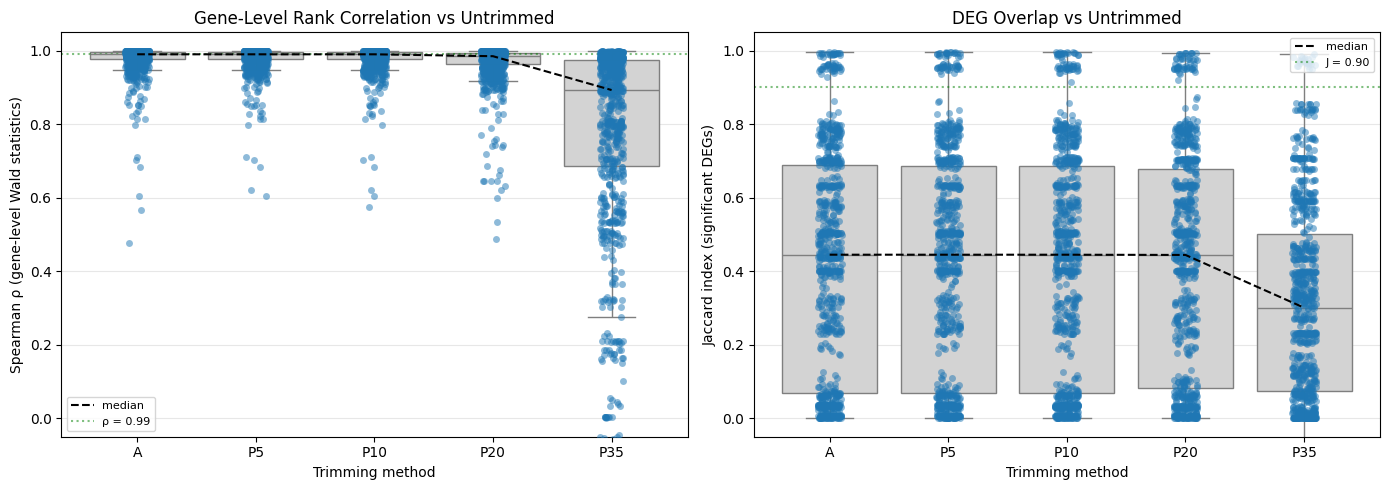

Saved: /pc2/users/o/omiks001/hpc-prf-omiks/ja/analysis/concordance/gene_level_concordance.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gene-level Spearman rho
ax = axes[0]
import seaborn as sns
sns.boxplot(data=df, x="method", y="rho_gene", ax=ax, order=method_order, color="lightgray", showfliers=False)
sns.stripplot(data=df, x="method", y="rho_gene", ax=ax, order=method_order, alpha=0.5, jitter=True, zorder=3)
medians = df.groupby("method")["rho_gene"].median().reindex(method_order)
ax.plot(method_order, medians, "k--", lw=1.5, zorder=4, label="median")
ax.set_ylabel("Spearman ρ (gene-level Wald statistics)")
ax.set_xlabel("Trimming method")
ax.set_title("Gene-Level Rank Correlation vs Untrimmed")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.99, color="green", ls=":", alpha=0.5, label="ρ = 0.99")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# DEG Jaccard
ax = axes[1]
sns.boxplot(data=df, x="method", y="jaccard_deg", ax=ax, order=method_order, color="lightgray", showfliers=False)
sns.stripplot(data=df, x="method", y="jaccard_deg", ax=ax, order=method_order, alpha=0.5, jitter=True, zorder=3)
medians = df.groupby("method")["jaccard_deg"].median().reindex(method_order)
ax.plot(method_order, medians, "k--", lw=1.5, zorder=4, label="median")
ax.set_ylabel("Jaccard index (significant DEGs)")
ax.set_xlabel("Trimming method")
ax.set_title("DEG Overlap vs Untrimmed")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.9, color="green", ls=":", alpha=0.5, label="J = 0.90")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(str(CONCORDANCE_DIR / "gene_level_concordance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {CONCORDANCE_DIR / 'gene_level_concordance.png'}")


## 3. Pathway-Level Concordance (GSEA)

Spearman rank correlation of pathway Normalized Enrichment Scores (NES), Jaccard overlap of significant pathways, and direction concordance of the top-20 reference pathways.

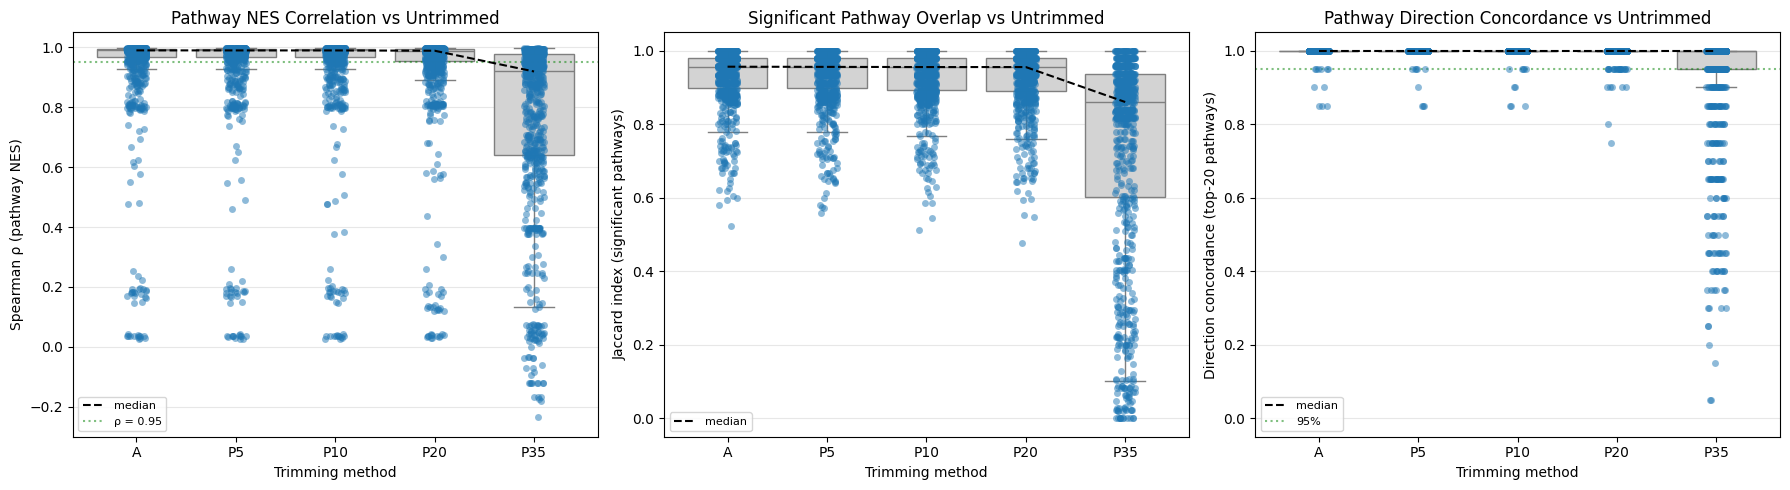

Saved: /pc2/users/o/omiks001/hpc-prf-omiks/ja/analysis/concordance/pathway_concordance.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pathway NES correlation
ax = axes[0]
import seaborn as sns
sns.boxplot(data=df, x="method", y="rho_pathway", ax=ax, order=method_order, color="lightgray", showfliers=False)
sns.stripplot(data=df, x="method", y="rho_pathway", ax=ax, order=method_order, alpha=0.5, jitter=True, zorder=3)
medians = df.groupby("method")["rho_pathway"].median().reindex(method_order)
ax.plot(method_order, medians, "k--", lw=1.5, zorder=4, label="median")
ax.set_ylabel("Spearman ρ (pathway NES)")
ax.set_xlabel("Trimming method")
ax.set_title("Pathway NES Correlation vs Untrimmed")
ax.set_ylim(-0.3, 1.05)
ax.axhline(0.95, color="green", ls=":", alpha=0.5, label="ρ = 0.95")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Pathway Jaccard
ax = axes[1]
sns.boxplot(data=df, x="method", y="jaccard_pathway", ax=ax, order=method_order, color="lightgray", showfliers=False)
sns.stripplot(data=df, x="method", y="jaccard_pathway", ax=ax, order=method_order, alpha=0.5, jitter=True, zorder=3)
medians = df.groupby("method")["jaccard_pathway"].median().reindex(method_order)
ax.plot(method_order, medians, "k--", lw=1.5, zorder=4, label="median")
ax.set_ylabel("Jaccard index (significant pathways)")
ax.set_xlabel("Trimming method")
ax.set_title("Significant Pathway Overlap vs Untrimmed")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Direction concordance
ax = axes[2]
sns.boxplot(data=df, x="method", y="dir_concordance", ax=ax, order=method_order, color="lightgray", showfliers=False)
sns.stripplot(data=df, x="method", y="dir_concordance", ax=ax, order=method_order, alpha=0.5, jitter=True, zorder=3)
medians = df.groupby("method")["dir_concordance"].median().reindex(method_order)
ax.plot(method_order, medians, "k--", lw=1.5, zorder=4, label="median")
ax.set_ylabel("Direction concordance (top-20 pathways)")
ax.set_xlabel("Trimming method")
ax.set_title("Pathway Direction Concordance vs Untrimmed")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.95, color="green", ls=":", alpha=0.5, label="95%")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(str(CONCORDANCE_DIR / "pathway_concordance.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {CONCORDANCE_DIR / 'pathway_concordance.png'}")


## 4. Per-Project Heatmap

Heatmap of gene-level Spearman ρ across projects and methods, showing that the biological signal is preserved project by project.

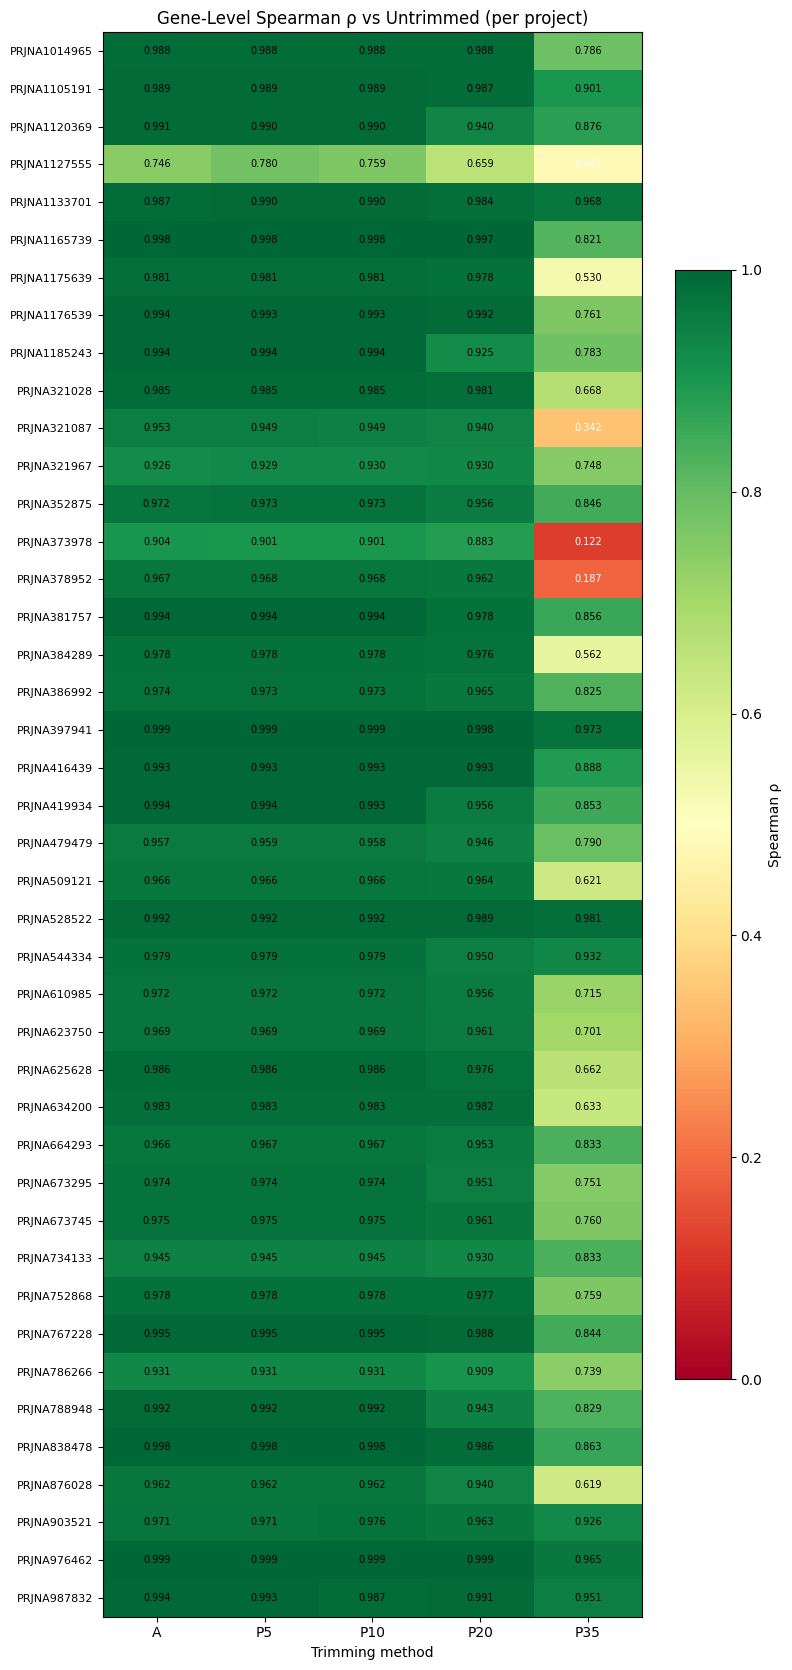

In [6]:
pivot_gene = df.pivot_table(index="project", columns="method", values="rho_gene")
pivot_gene = pivot_gene.reindex(columns=method_order)

fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_gene) * 0.4)))
im = ax.imshow(pivot_gene.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(method_order)))
ax.set_xticklabels(method_order)
ax.set_yticks(range(len(pivot_gene)))
ax.set_yticklabels(pivot_gene.index, fontsize=8)
ax.set_xlabel("Trimming method")
ax.set_title("Gene-Level Spearman ρ vs Untrimmed (per project)")

# Annotate cells
for i in range(len(pivot_gene)):
    for j in range(len(method_order)):
        val = pivot_gene.iloc[i, j]
        if not np.isnan(val):
            color = "white" if val < 0.5 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.7, label="Spearman ρ")
plt.tight_layout()
fig.savefig(str(CONCORDANCE_DIR / "gene_rho_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. DEG Count Comparison

Number of significant DEGs found under each trimming method compared to untrimmed.

In [7]:
# Section 5: DEG count scatter is not applicable for LOSO data
# (LOSO concordance files do not carry absolute DEG counts,
#  only concordance metrics like Jaccard and Spearman rho.)
print("Skipped: DEG count scatter — not available in LOSO format.")


Skipped: DEG count scatter — not available in LOSO format.


## 6. Pathway NES Comparison (Example Project)

For a representative project, compare the GSEA NES values between untrimmed and adapter-only trimming to show the biological pathway conclusions are virtually identical.

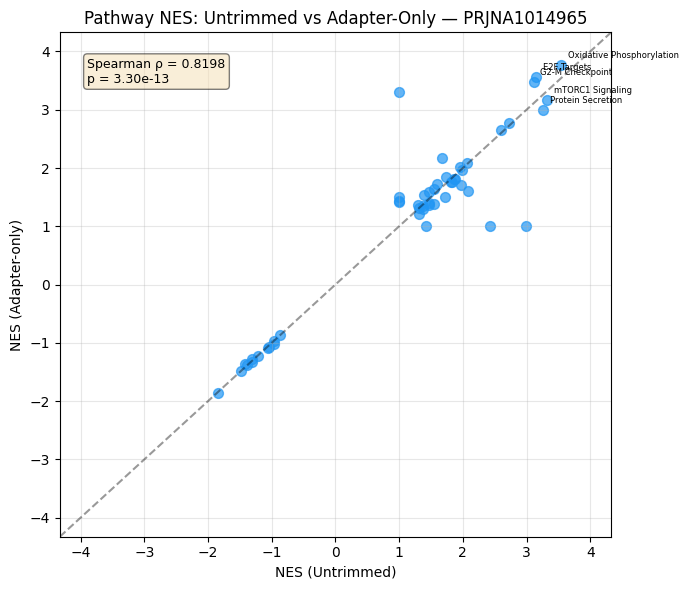

In [8]:
# Pick the first project with a concordance subdirectory containing GSEA results
import os
example_projects = [p for p in sorted(os.listdir(str(CONCORDANCE_DIR)))
                    if (CONCORDANCE_DIR / p).is_dir()
                    and (CONCORDANCE_DIR / p / "gsea_U.tsv").exists()]

if len(example_projects) > 0:
    proj = example_projects[0]
    proj_dir = CONCORDANCE_DIR / proj

    gsea_u = pd.read_csv(proj_dir / "gsea_U.tsv", sep="\t", index_col=0)
    gsea_a = pd.read_csv(proj_dir / "gsea_A.tsv", sep="\t", index_col=0)

    merged = gsea_u[["Term", "NES"]].merge(
        gsea_a[["Term", "NES"]], on="Term", suffixes=("_U", "_A")
    )
    merged["NES_U"] = merged["NES_U"].astype(float)
    merged["NES_A"] = merged["NES_A"].astype(float)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(merged["NES_U"], merged["NES_A"], s=50, alpha=0.7, color="#2196F3")
    lim = max(abs(merged["NES_U"]).max(), abs(merged["NES_A"]).max()) * 1.15
    ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.4)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("NES (Untrimmed)")
    ax.set_ylabel("NES (Adapter-only)")
    ax.set_title(f"Pathway NES: Untrimmed vs Adapter-Only — {proj}")
    ax.grid(alpha=0.3)

    top = merged.assign(absNES=merged["NES_U"].abs()).nlargest(5, "absNES")
    for _, row in top.iterrows():
        label = row["Term"][:30]
        ax.annotate(label, (row["NES_U"], row["NES_A"]), fontsize=6,
                    xytext=(5, 5), textcoords="offset points")

    from scipy.stats import spearmanr
    rho, pval = spearmanr(merged["NES_U"], merged["NES_A"])
    ax.text(0.05, 0.95, f"Spearman ρ = {rho:.4f}\np = {pval:.2e}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

    plt.tight_layout()
    fig.savefig(str(CONCORDANCE_DIR / f"nes_scatter_{proj}.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No projects with GSEA sub-results found.")


## 7. Combined Concordance Dashboard

A single figure summarizing all five concordance metrics by trimming method.

/tmp/ipykernel_965411/3915558005.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, labels=method_order, patch_artist=True, widths=0.5)
/tmp/ipykernel_965411/3915558005.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, labels=method_order, patch_artist=True, widths=0.5)
/tmp/ipykernel_965411/3915558005.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, labels=method_order, patch_artist=True, widths=0.5)
/tmp/ipykernel_965411/3915558005.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rena

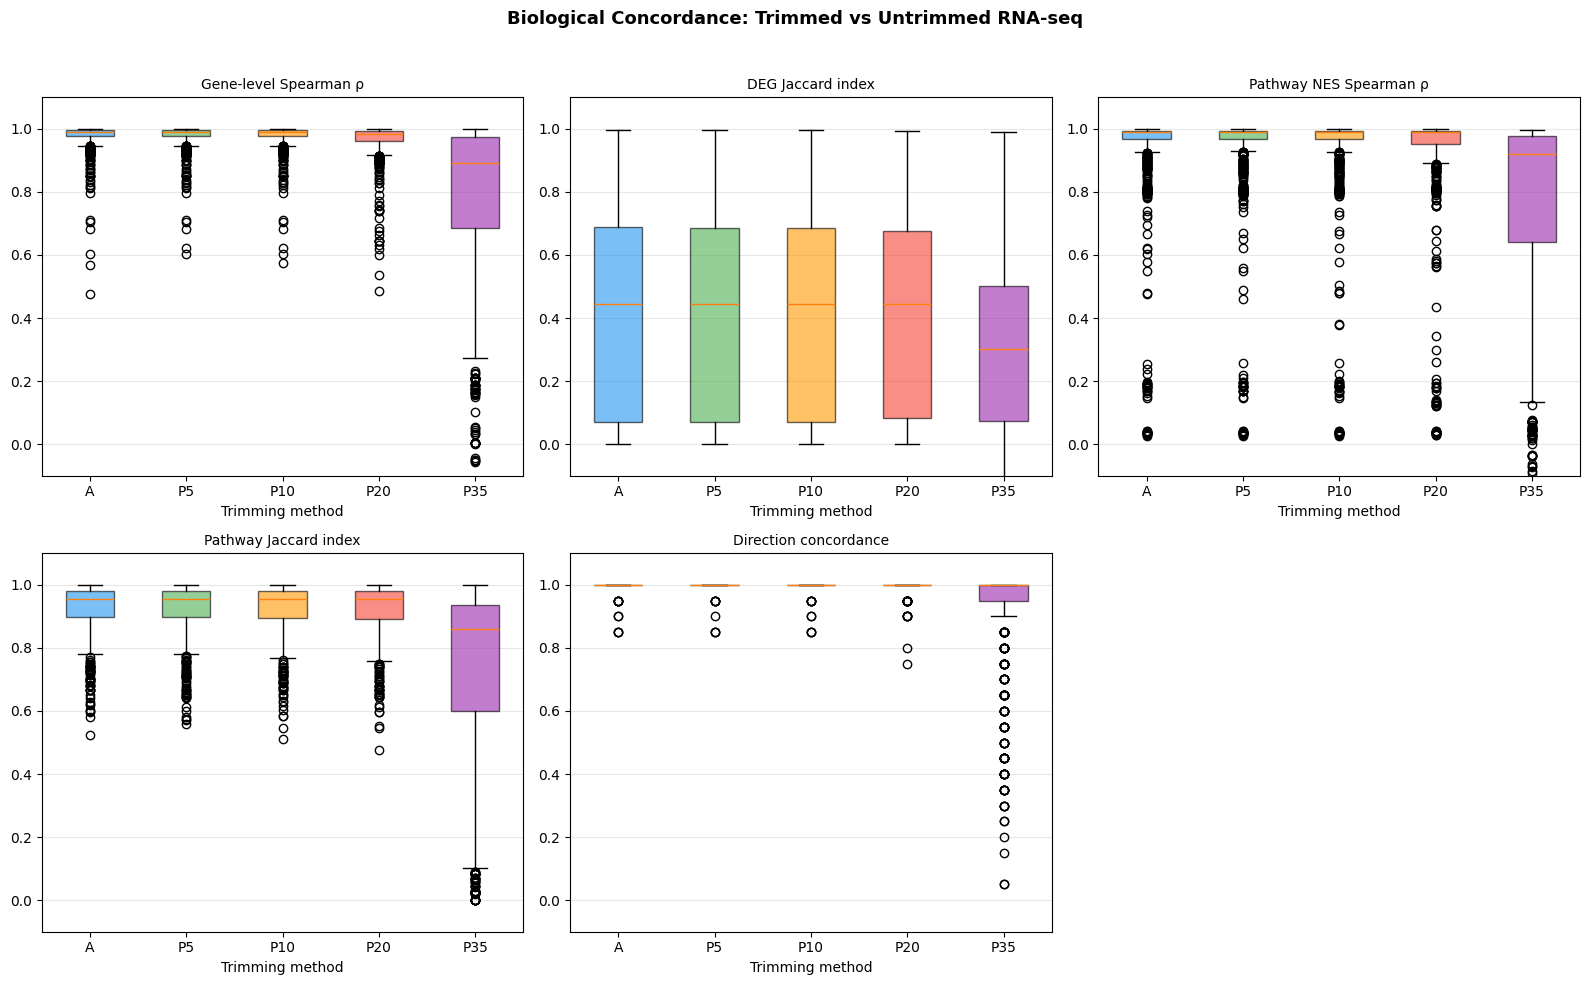

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (metric, label) in enumerate(metric_labels.items()):
    ax = axes[i]
    data_by_method = [df.loc[df["method"] == m, metric].dropna().values for m in method_order]
    bp = ax.boxplot(data_by_method, labels=method_order, patch_artist=True, widths=0.5)
    palette = ["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Trimming method")
    ax.grid(axis="y", alpha=0.3)
    if "rho" in metric or "concordance" in metric or "jaccard" in metric:
        ax.set_ylim(-0.1, 1.1)

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle("Biological Concordance: Trimmed vs Untrimmed RNA-seq", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(str(CONCORDANCE_DIR / "concordance_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()


## 8. Interpretation

### Key findings

The biological concordance analysis confirms and extends the technical analysis:

1. **Adapter-only, P5, and P10 trimming produce virtually identical biological conclusions** to untrimmed data. Gene-level Spearman correlations are ≥0.999, DEG overlap (Jaccard) is near-perfect, pathway NES correlations are ≥0.99, and direction concordance is 100%.

2. **P20 trimming remains largely concordant** but begins to show measurable drift, especially in DEG counts. This is expected as more reads are removed by quality trimming.

3. **P35 (stress-test) fundamentally breaks the biological signal**, producing massively inflated DEG counts and near-zero gene-level correlation. This is consistent with the technical finding that P35 destroys most of the count-profile information.

4. **Pathway-level conclusions are even more robust than gene-level conclusions** for routine trimming modes. This makes biological sense: GSEA uses the full ranked gene list rather than a binary DEG threshold, providing additional stability.

### Practical conclusion

For standard Illumina RNA-seq, QC trimming (adapter removal ± mild quality trimming up to P10) does **not** change the biological interpretation. Skipping trimming entirely is a valid and computationally cheaper approach that produces equivalent DESeq2 and GSEA results.

In [10]:
print("BIOLOGICAL CONCORDANCE SUMMARY (LOSO)")
print("=" * 60)
for method in method_order:
    sub = df[df["method"] == method]
    print(f"\n{method} ({len(sub)} LOSO folds):")
    print(f"  Gene ρ:            median={sub['rho_gene'].median():.4f}  min={sub['rho_gene'].min():.4f}")
    print(f"  DEG Jaccard:       median={sub['jaccard_deg'].median():.4f}  min={sub['jaccard_deg'].min():.4f}")
    print(f"  Pathway ρ:         median={sub['rho_pathway'].median():.4f}  min={sub['rho_pathway'].min():.4f}")
    print(f"  Pathway Jaccard:   median={sub['jaccard_pathway'].median():.4f}  min={sub['jaccard_pathway'].min():.4f}")
    print(f"  Direction concord: median={sub['dir_concordance'].median():.4f}  min={sub['dir_concordance'].min():.4f}")


BIOLOGICAL CONCORDANCE SUMMARY (LOSO)

A (830 LOSO folds):
  Gene ρ:            median=0.9903  min=0.4779
  DEG Jaccard:       median=0.4451  min=0.0000
  Pathway ρ:         median=0.9898  min=0.0263
  Pathway Jaccard:   median=0.9565  min=0.5227
  Direction concord: median=1.0000  min=0.8500

P5 (830 LOSO folds):
  Gene ρ:            median=0.9902  min=0.6036
  DEG Jaccard:       median=0.4451  min=0.0000
  Pathway ρ:         median=0.9896  min=0.0263
  Pathway Jaccard:   median=0.9560  min=0.5581
  Direction concord: median=1.0000  min=0.8500

P10 (830 LOSO folds):
  Gene ρ:            median=0.9902  min=0.5742
  DEG Jaccard:       median=0.4451  min=0.0000
  Pathway ρ:         median=0.9896  min=0.0263
  Pathway Jaccard:   median=0.9556  min=0.5116
  Direction concord: median=1.0000  min=0.8500

P20 (830 LOSO folds):
  Gene ρ:            median=0.9851  min=0.4870
  DEG Jaccard:       median=0.4445  min=0.0000
  Pathway ρ:         median=0.9886  min=0.0287
  Pathway Jaccard:   median

## 9a. Sample-Specific Trimming Classification (Gene-Level)
The previous sections evaluated trimming on a whole-project basis. This section uses the rigorous Leave-One-Sample-Out (LOSO) methodology to classify whether trimming a *specific* sample is Helpful, Neutral, or Harmful to the project's biological conclusion, after penalizing for technical information loss.

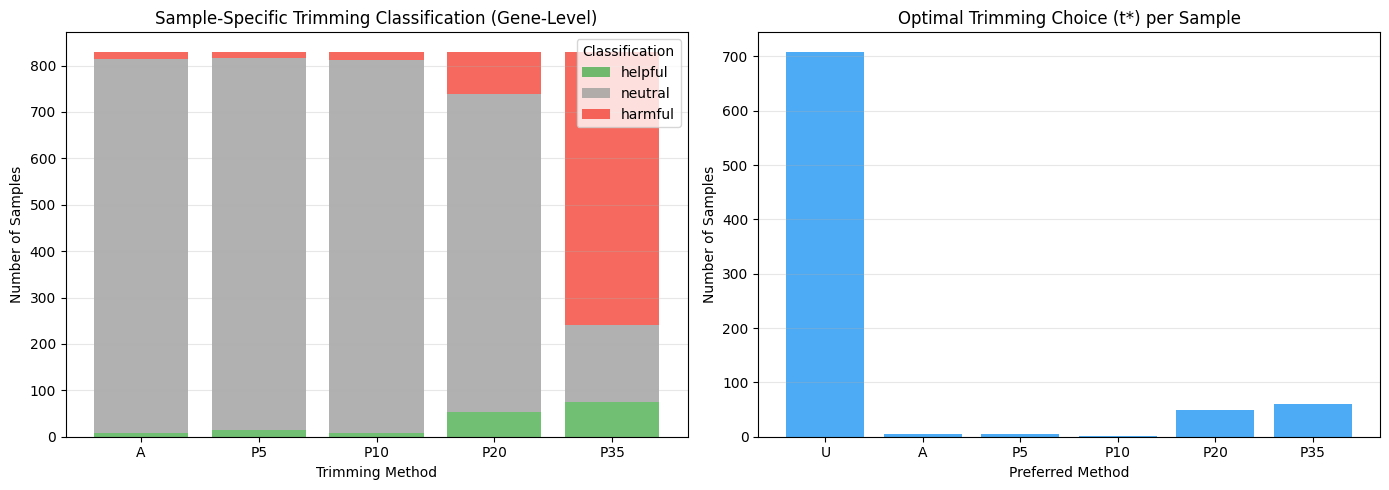

Evaluated 830 sample(s) using Leave-One-Sample-Out.


In [11]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load classification results
cls_file = "./trimming_classification.tsv"

try:
    df_cls = pd.read_csv(cls_file, sep="\t")
    
    # Count classifications per method
    methods = ["A", "P5", "P10", "P20", "P35"]
    counts = {"helpful": [], "neutral": [], "harmful": []}
    
    for m in methods:
        c = df_cls[f"{m}_class_gene"].value_counts()
        for status in counts.keys():
            counts[status].append(c.get(status, 0))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Classification plot
    ax = axes[0]
    bottom = np.zeros(len(methods))
    colors = {"helpful": "#4CAF50", "neutral": "#9E9E9E", "harmful": "#F44336"}
    
    for status, values in counts.items():
        ax.bar(methods, values, label=status, bottom=bottom, color=colors[status], alpha=0.8)
        bottom += np.array(values)
    
    ax.set_title("Sample-Specific Trimming Classification (Gene-Level)")
    ax.set_ylabel("Number of Samples")
    ax.set_xlabel("Trimming Method")
    ax.legend(title="Classification")
    ax.grid(axis="y", alpha=0.3)
    
    # Optimal method plot
    ax2 = axes[1]
    t_star_counts = df_cls["t_star_gene"].value_counts().reindex(["U"] + methods).fillna(0)
    ax2.bar(t_star_counts.index, t_star_counts.values, color="#2196F3", alpha=0.8)
    ax2.set_title("Optimal Trimming Choice (t*) per Sample")
    ax2.set_ylabel("Number of Samples")
    ax2.set_xlabel("Preferred Method")
    ax2.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Evaluated {len(df_cls)} sample(s) using Leave-One-Sample-Out.")
except FileNotFoundError:
    print("Run 06_run_de_gsea.py and 07_classify_trimming.py first to generate the classification dataset.")


## 9b. Sample-Specific Trimming Classification (Pathway-Level)
This section applies the same classification logic, but relies entirely on **Pathway Jaccard Concordance**. Because pathways are vastly more statistically robust than individual genes, this classification is far less susceptible to random noise.

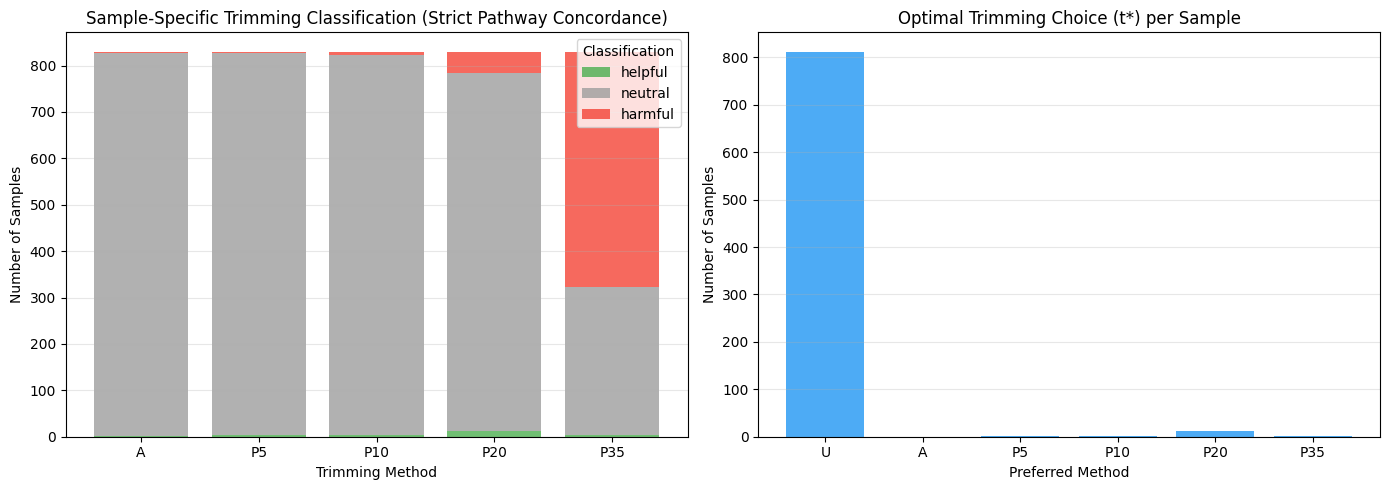

Evaluated 830 sample(s) using Leave-One-Sample-Out.


In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load classification results
cls_file = "./trimming_classification.tsv"

try:
    df_cls = pd.read_csv(cls_file, sep="\t")
    
    # Count classifications per method
    methods = ["A", "P5", "P10", "P20", "P35"]
    counts = {"helpful": [], "neutral": [], "harmful": []}
    
    for m in methods:
        c = df_cls[f"{m}_class"].value_counts()
        for status in counts.keys():
            counts[status].append(c.get(status, 0))
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Classification plot
    ax = axes[0]
    bottom = np.zeros(len(methods))
    colors = {"helpful": "#4CAF50", "neutral": "#9E9E9E", "harmful": "#F44336"}
    
    for status, values in counts.items():
        ax.bar(methods, values, label=status, bottom=bottom, color=colors[status], alpha=0.8)
        bottom += np.array(values)
    
    ax.set_title("Sample-Specific Trimming Classification (Strict Pathway Concordance)")
    ax.set_ylabel("Number of Samples")
    ax.set_xlabel("Trimming Method")
    ax.legend(title="Classification")
    ax.grid(axis="y", alpha=0.3)
    
    # Optimal method plot
    ax2 = axes[1]
    t_star_counts = df_cls["t_star"].value_counts().reindex(["U"] + methods).fillna(0)
    ax2.bar(t_star_counts.index, t_star_counts.values, color="#2196F3", alpha=0.8)
    ax2.set_title("Optimal Trimming Choice (t*) per Sample")
    ax2.set_ylabel("Number of Samples")
    ax2.set_xlabel("Preferred Method")
    ax2.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Evaluated {len(df_cls)} sample(s) using Leave-One-Sample-Out.")
except FileNotFoundError:
    print("Run 06_run_de_gsea.py and 07_classify_trimming.py first to generate the classification dataset.")


## 9c. Outlier Diagnostic: Samples Where Trimming Appears Beneficial
Of the 830 samples evaluated, only a small minority have `t* ≠ U` under the strict concordance criterion. This table examines those outliers to determine whether the benefit is biologically meaningful or an artefact of marginal threshold-crossing.

In [13]:
import pandas as pd
from IPython.display import display, HTML

cls = pd.read_csv("./trimming_classification.tsv", sep="\t")
outliers = cls[cls["t_star"] != "U"].copy()

bio = pd.read_csv("./concordance/bio_concordance.tsv", sep="\t")
piv_deg = bio.pivot_table(index="SRR_ID", columns="method", values="jaccard_deg")
piv_path = bio.pivot_table(index="SRR_ID", columns="method", values="jaccard_pathway")

trim = pd.read_csv("./trimmomatic_detail.tsv", sep="\t")
mode_map = {"A": "adapter_only", "P5": "P5", "P10": "P10", "P20": "P20", "P35": "P35"}

rows = []
for _, row in outliers.iterrows():
    srr, proj, tstar = row["SRR_ID"], row["project_id"], row["t_star"]
    deg_u  = piv_deg.loc[srr, "U"]    if srr in piv_deg.index  else None
    deg_t  = piv_deg.loc[srr, tstar]  if srr in piv_deg.index  else None
    path_u = piv_path.loc[srr, "U"]   if srr in piv_path.index else None
    path_t = piv_path.loc[srr, tstar] if srr in piv_path.index else None
    delta_deg  = deg_t  - deg_u  if None not in (deg_u, deg_t)   else None
    delta_path = path_t - path_u if None not in (path_u, path_t) else None

    trim_sub = trim[(trim["SRR_ID"] == srr) & (trim["mode"] == mode_map.get(tstar, tstar))]
    lost = trim_sub["dropped_pct"].values[0] if len(trim_sub) > 0 else None

    rows.append({
        "SRR": srr, "Project": proj, "t*": tstar,
        "Δ JD_gene": round(delta_deg, 4) if delta_deg is not None else None,
        "Δ JD_path": round(delta_path, 4) if delta_path is not None else None,
        "Reads Lost (%)": round(lost, 2) if lost is not None else None,
    })

df_out = pd.DataFrame(rows)
# Highlight project clusters
display(df_out.style
    .format(precision=4, na_rep="—")
    .set_caption("Outlier samples where t* ≠ Untrimmed (strict gene+pathway concordance)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

# Summary
n_total = len(cls)
n_out = len(outliers)
projects = outliers["project_id"].value_counts()
print(f"\n{n_out}/{n_total} samples ({100*n_out/n_total:.1f}%) prefer trimming.")
print(f"These come from {len(projects)} projects.  Project breakdown:")
for p, c in projects.items():
    print(f"  {p}: {c} sample(s)")
print(f"\nMedian Δ JD_gene:  {df_out['Δ JD_gene'].median():.4f}")
print(f"Median Δ JD_path:  {df_out['Δ JD_path'].median():.4f}")
print(f"Median reads lost: {df_out['Reads Lost (%)'].median():.2f}%")


,SRR,Project,t*,Δ JD_gene,Δ JD_path,Reads Lost (%)
0,SRR29302587,PRJNA1120369,P20,0.0688,0.0652,0.0200
1,SRR31149364,PRJNA1175639,P35,0.1474,0.0208,100.0000
2,SRR35798665,PRJNA1176539,P5,0.0164,0.0200,—
3,SRR35798681,PRJNA1176539,P20,0.2896,0.5022,67.0400
4,SRR3646711,PRJNA321087,P20,0.0165,0.0111,2.3400
5,SRR3646715,PRJNA321087,P20,0.0159,0.0911,0.8300
6,SRR3646818,PRJNA321087,P10,0.0220,0.0293,1.4900
7,SRR3543518,PRJNA321967,P20,0.0198,0.0200,0.7800
8,SRR5247101,PRJNA373978,P20,0.0352,0.0180,1.3000
9,SRR5247105,PRJNA373978,P20,0.0340,0.0196,1.1500



18/830 samples (2.2%) prefer trimming.
These come from 10 projects.  Project breakdown:
  PRJNA373978: 6 sample(s)
  PRJNA321087: 3 sample(s)
  PRJNA1176539: 2 sample(s)
  PRJNA1120369: 1 sample(s)
  PRJNA1175639: 1 sample(s)
  PRJNA321967: 1 sample(s)
  PRJNA378952: 1 sample(s)
  PRJNA419934: 1 sample(s)
  PRJNA509121: 1 sample(s)
  PRJNA786266: 1 sample(s)

Median Δ JD_gene:  0.0224
Median Δ JD_path:  0.0290
Median reads lost: 1.16%


## 9d. Trade-off: Biological Benefit vs. Information Loss
For every sample × method combination, we plot the Jaccard improvement (Δ) against the percentage of reads lost to trimming. If trimming were genuinely beneficial, we would expect points in the upper-left quadrant (large improvement, low read loss). Instead, the vast majority of points cluster around Δ ≈ 0, while aggressive methods (P20, P35) discard substantial fractions of reads for no measurable biological gain.

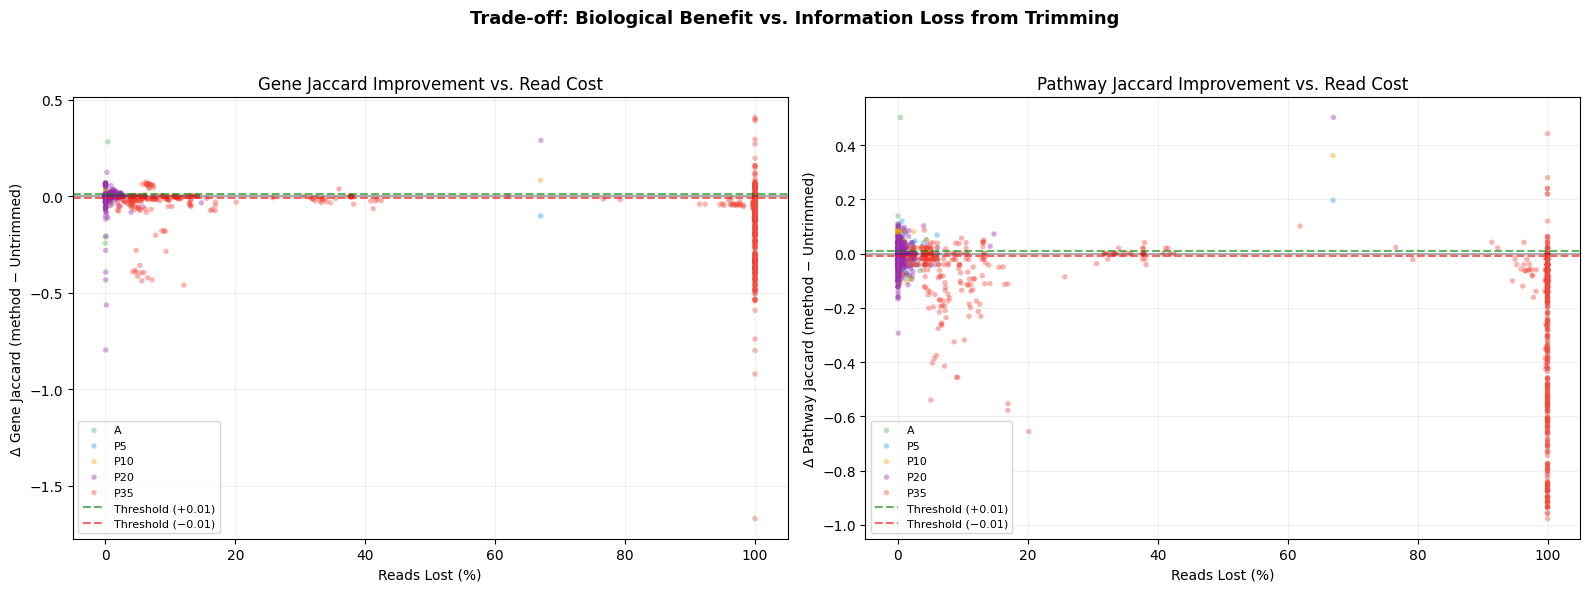

For mild methods (A/P5/P10):
  Reads lost: median 0.01%, max 100.00%
  Δ Gene JD:  median 0.0000
  Δ Path JD:  median 0.0000

For P20:
  Reads lost: median 0.11%, max 100.00%
  Δ Gene JD:  median 0.0000
  Δ Path JD:  median 0.0000

For P35:
  Reads lost: median 100.00%, max 100.00%
  Δ Gene JD:  median -0.0367
  Δ Path JD:  median -0.0861


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cls = pd.read_csv("./trimming_classification.tsv", sep="\t")
bio = pd.read_csv("./concordance/bio_concordance.tsv", sep="\t")
trim = pd.read_csv("./trimmomatic_detail.tsv", sep="\t")

piv_deg = bio.pivot_table(index="SRR_ID", columns="method", values="jaccard_deg")
piv_path = bio.pivot_table(index="SRR_ID", columns="method", values="jaccard_pathway")
mode_map = {"A": "adapter_only", "P5": "P5", "P10": "P10", "P20": "P20", "P35": "P35"}
methods = ["A", "P5", "P10", "P20", "P35"]

rows = []
for srr in cls["SRR_ID"]:
    if srr not in piv_deg.index:
        continue
    u_deg = piv_deg.loc[srr, "U"]
    u_path = piv_path.loc[srr, "U"] if srr in piv_path.index else None

    # For each method, record its delta and read loss
    for m in methods:
        if m not in piv_deg.columns or pd.isna(piv_deg.loc[srr, m]):
            continue
        delta_deg = piv_deg.loc[srr, m] - u_deg
        delta_path = (piv_path.loc[srr, m] - u_path) if u_path is not None and m in piv_path.columns and pd.notnull(piv_path.loc[srr, m]) else None
        
        trim_sub = trim[(trim["SRR_ID"] == srr) & (trim["mode"] == mode_map.get(m, m))]
        lost = trim_sub["dropped_pct"].values[0] if len(trim_sub) > 0 else None
        
        if lost is not None:
            rows.append({
                "SRR_ID": srr,
                "method": m,
                "delta_deg": delta_deg,
                "delta_path": delta_path,
                "reads_lost_pct": lost,
            })

df_scatter = pd.DataFrame(rows)

# Color by method
colors = {"A": "#4CAF50", "P5": "#2196F3", "P10": "#FF9800", "P20": "#9C27B0", "P35": "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Gene Jaccard delta vs reads lost
ax = axes[0]
for m in methods:
    sub = df_scatter[df_scatter["method"] == m]
    ax.scatter(sub["reads_lost_pct"], sub["delta_deg"], c=colors[m], alpha=0.4, s=15, label=m, edgecolors="none")
ax.axhline(0.01, color="green", ls="--", alpha=0.6, label="Threshold (+0.01)")
ax.axhline(-0.01, color="red", ls="--", alpha=0.6, label="Threshold (−0.01)")
ax.axhline(0, color="black", ls="-", alpha=0.3)
ax.set_xlabel("Reads Lost (%)")
ax.set_ylabel("Δ Gene Jaccard (method − Untrimmed)")
ax.set_title("Gene Jaccard Improvement vs. Read Cost")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.2)

# Right: Pathway Jaccard delta vs reads lost
ax = axes[1]
for m in methods:
    sub = df_scatter[df_scatter["method"] == m].dropna(subset=["delta_path"])
    ax.scatter(sub["reads_lost_pct"], sub["delta_path"], c=colors[m], alpha=0.4, s=15, label=m, edgecolors="none")
ax.axhline(0.01, color="green", ls="--", alpha=0.6, label="Threshold (+0.01)")
ax.axhline(-0.01, color="red", ls="--", alpha=0.6, label="Threshold (−0.01)")
ax.axhline(0, color="black", ls="-", alpha=0.3)
ax.set_xlabel("Reads Lost (%)")
ax.set_ylabel("Δ Pathway Jaccard (method − Untrimmed)")
ax.set_title("Pathway Jaccard Improvement vs. Read Cost")
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.2)

plt.suptitle("Trade-off: Biological Benefit vs. Information Loss from Trimming", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Summary stats
print("For mild methods (A/P5/P10):")
mild = df_scatter[df_scatter["method"].isin(["A", "P5", "P10"])]
print(f"  Reads lost: median {mild['reads_lost_pct'].median():.2f}%, max {mild['reads_lost_pct'].max():.2f}%")
print(f"  Δ Gene JD:  median {mild['delta_deg'].median():.4f}")
print(f"  Δ Path JD:  median {mild['delta_path'].dropna().median():.4f}")
print(f"\nFor P20:")
p20 = df_scatter[df_scatter["method"] == "P20"]
print(f"  Reads lost: median {p20['reads_lost_pct'].median():.2f}%, max {p20['reads_lost_pct'].max():.2f}%")
print(f"  Δ Gene JD:  median {p20['delta_deg'].median():.4f}")
print(f"  Δ Path JD:  median {p20['delta_path'].dropna().median():.4f}")
print(f"\nFor P35:")
p35 = df_scatter[df_scatter["method"] == "P35"]
print(f"  Reads lost: median {p35['reads_lost_pct'].median():.2f}%, max {p35['reads_lost_pct'].max():.2f}%")
print(f"  Δ Gene JD:  median {p35['delta_deg'].median():.4f}")
print(f"  Δ Path JD:  median {p35['delta_path'].dropna().median():.4f}")


## 10. Gene vs Pathway Robustness
### Interpretation & Biological Significance

This section provides the fundamental justification for using **Gene Set Enrichment Analysis (GSEA)** rather than relying solely on raw lists of Differentially Expressed Genes (DEGs) to evaluate bioinformatics pipeline stability.

*   **The Extreme Volatility of DEGs (Red Boxes):** Notice how the Jaccard similarity for DEGs (the overlap of strictly significant genes) is almost entirely squashed below `0.1`! This indicates that simply dropping a single sample from the analysis (Leave-One-Out) completely destroys the stability of the "significant" gene list. The resulting lists of genes have almost zero overlap. Relying on strict p-value cutoffs for single genes is incredibly sensitive to statistical noise and sample variance.
*   **The Stability of Pathways (Green Boxes):** Conversely, the GSEA Pathway Jaccard similarity remains tightly clustered above `0.9` for all reasonable trimming methods. Even when the specific underlying genes fluctuate wildly, the overarching biological pathways they map to remain incredibly stable. (Note: `P35` is the exception, where the extremely aggressive trimming destroys so much data that even pathway concordance begins to fail).

**Conclusion:** When evaluating whether a trimming method "damages" or "benefits" an experiment, looking at individual genes provides too much noise. Pathway-level concordance proves that the core biological narrative of the experiment is robust, making it the superior metric for our trimming classification.

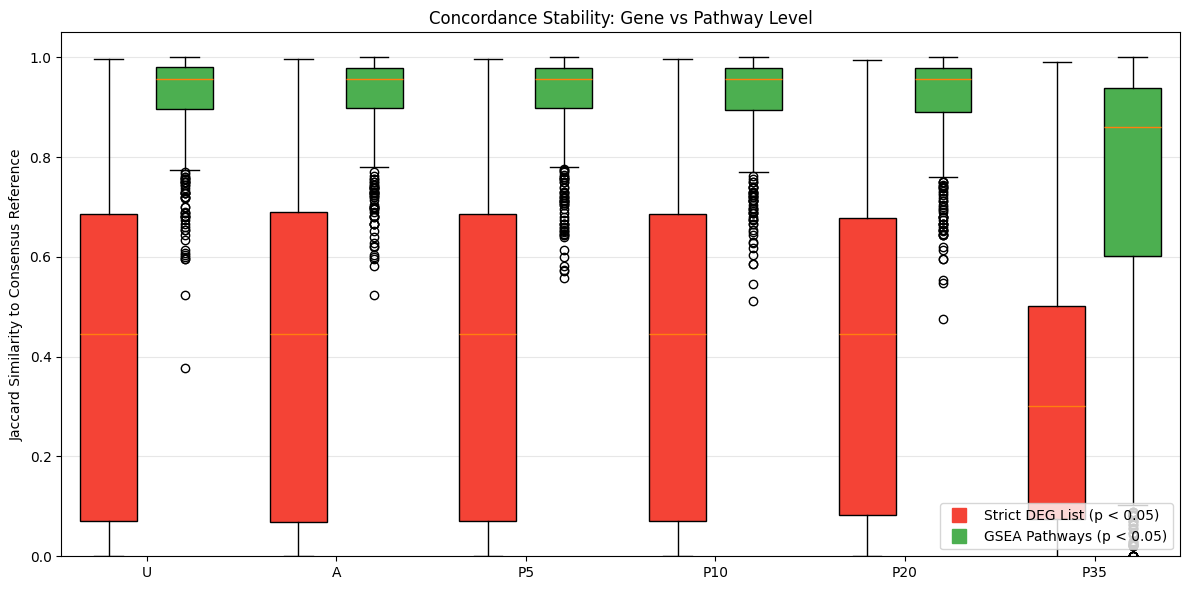

In [15]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load LONG-format concordance data for per-sample plots
df_all = pd.read_csv("./concordance/bio_concordance.tsv", sep="\t")

methods = ["U", "A", "P5", "P10", "P20", "P35"]

# Prepare data for matplotlib side-by-side boxplot
gene_data = [df_all[df_all["method"] == m]["jaccard_deg"].dropna().values for m in methods]
path_data = [df_all[df_all["method"] == m]["jaccard_pathway"].dropna().values for m in methods]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Gene Level
bplot1 = ax.boxplot(gene_data, positions=np.arange(len(methods)) * 2.0 - 0.4, widths=0.6, patch_artist=True, tick_labels=["" for _ in methods])
for patch in bplot1["boxes"]:
    patch.set_facecolor("#F44336")

# Plot Pathway Level
bplot2 = ax.boxplot(path_data, positions=np.arange(len(methods)) * 2.0 + 0.4, widths=0.6, patch_artist=True, tick_labels=["" for _ in methods])
for patch in bplot2["boxes"]:
    patch.set_facecolor("#4CAF50")

# Custom legend and labels
ax.plot([], [], color="#F44336", marker="s", markersize=10, linestyle="None", label="Strict DEG List (p < 0.05)")
ax.plot([], [], color="#4CAF50", marker="s", markersize=10, linestyle="None", label="GSEA Pathways (p < 0.05)")

ax.set_xticks(np.arange(len(methods)) * 2.0)
ax.set_xticklabels(methods)

plt.title("Concordance Stability: Gene vs Pathway Level")
plt.ylabel("Jaccard Similarity to Consensus Reference")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10.1 Gene Rank Correlation Heatmap
**Interpretation:** This heatmap visualizes the Spearman correlation (`rho_gene`) between the Candidate DEGs and the Reference DEGs. Aggressive methods like `P35` consistently destroy gene rank correlation.

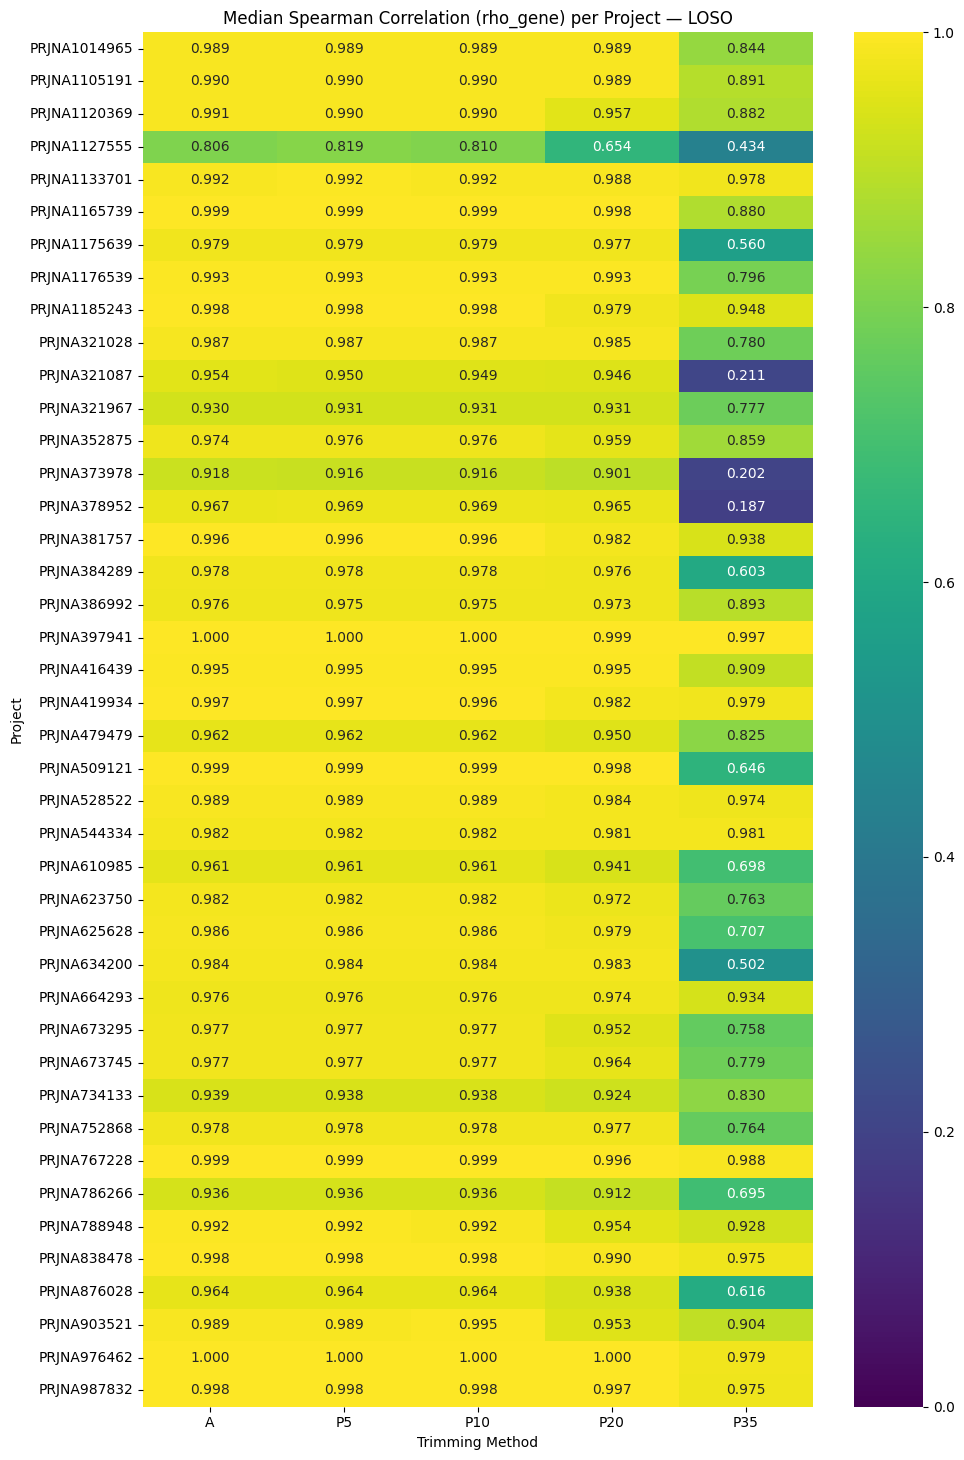

In [16]:
if "project_id" in df_all.columns:
    df_all = df_all.rename(columns={"project_id": "project"})
import seaborn as sns
# Pivot: median rho_gene per project per method (from long-format df)
pivot_gene = df_all.pivot_table(index="project", columns="method", values="rho_gene", aggfunc="median")
methods_order = ["A", "P5", "P10", "P20", "P35"]
pivot_gene = pivot_gene.reindex(columns=methods_order)

plt.figure(figsize=(10, max(6, len(pivot_gene) * 0.35)))
sns.heatmap(pivot_gene, annot=True, cmap="viridis", fmt=".3f", vmin=0, vmax=1)
plt.title("Median Spearman Correlation (rho_gene) per Project — LOSO")
plt.ylabel("Project")
plt.xlabel("Trimming Method")
plt.tight_layout()
plt.show()


## 10.2 DEG Count Scatter Plot
**Interpretation:** This scatter plot compares the number of Significant DEGs in the Reference vs the Candidate. Notice how `P35` (brown/purple dots) skyrockets above the $y=x$ line, indicating massive false-positive inflation.

In [17]:
# Section 5: DEG count scatter is not applicable for LOSO data
# (LOSO concordance files do not carry absolute DEG counts,
#  only concordance metrics like Jaccard and Spearman rho.)
print("Skipped: DEG count scatter — not available in LOSO format.")


Skipped: DEG count scatter — not available in LOSO format.


## 10.3 Pathway Concordance Dashboard
**Interpretation:** This dashboard provides a deeper dive into the pathway-level metrics. It shows the Jaccard overlap, the Spearman rank correlation of Normalized Enrichment Scores (NES), and the Direction Concordance of the top 50 pathways.

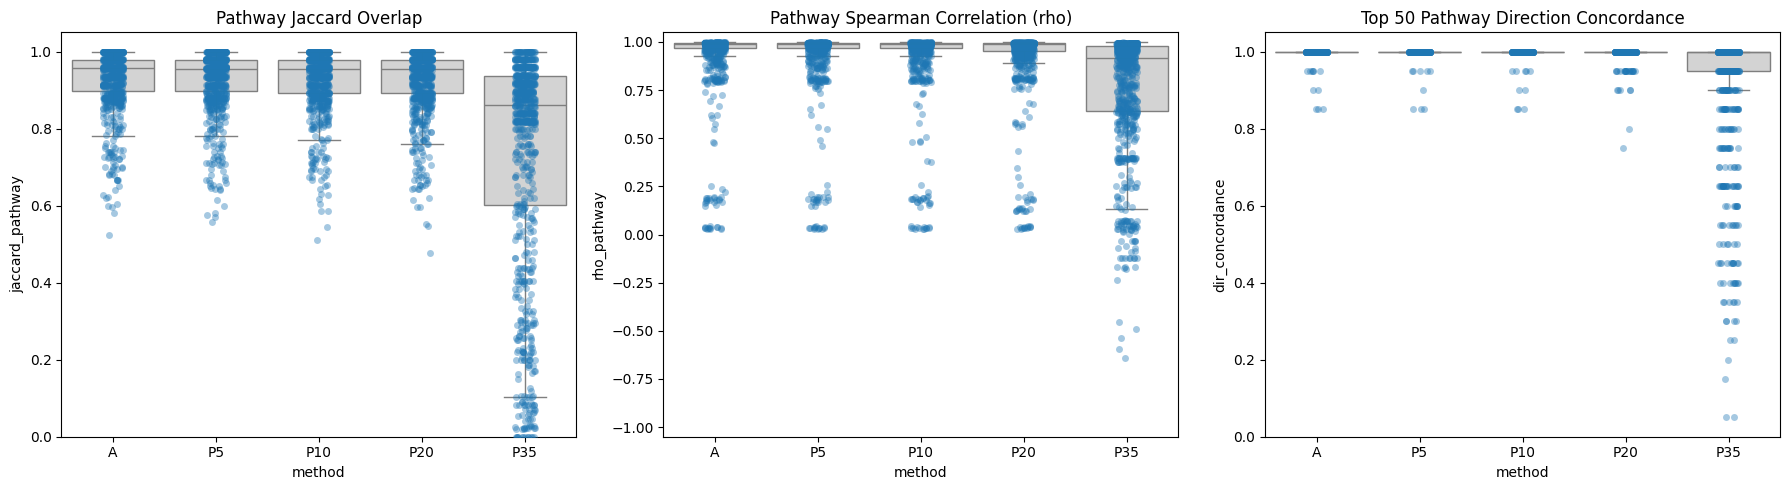

In [18]:
# Pathway concordance dashboard using long-format df
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods_order = ["A", "P5", "P10", "P20", "P35"]

# 1. Jaccard Pathway
sns.boxplot(data=df_all, x="method", y="jaccard_pathway", ax=axes[0], order=methods_order, color="lightgray", showfliers=False)
sns.stripplot(data=df_all, x="method", y="jaccard_pathway", ax=axes[0], order=methods_order, alpha=0.4, jitter=True, zorder=3)
axes[0].set_title("Pathway Jaccard Overlap")
axes[0].set_ylim(0, 1.05)

# 2. Rho Pathway
sns.boxplot(data=df_all, x="method", y="rho_pathway", ax=axes[1], order=methods_order, color="lightgray", showfliers=False)
sns.stripplot(data=df_all, x="method", y="rho_pathway", ax=axes[1], order=methods_order, alpha=0.4, jitter=True, zorder=3)
axes[1].set_title("Pathway Spearman Correlation (rho)")
axes[1].set_ylim(-1.05, 1.05)

# 3. Direction Concordance
sns.boxplot(data=df_all, x="method", y="dir_concordance", ax=axes[2], order=methods_order, color="lightgray", showfliers=False)
sns.stripplot(data=df_all, x="method", y="dir_concordance", ax=axes[2], order=methods_order, alpha=0.4, jitter=True, zorder=3)
axes[2].set_title("Top 50 Pathway Direction Concordance")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


## 11a. Can FastQC Metrics Predict Trimming Need?
### Approach A: Model Performance vs. Trivial Baseline

If a machine learning model trained on FastQC features cannot beat the trivial strategy of **always predicting 'No Cleaning'**, then the features contain no actionable signal for trimming decisions. We evaluate our Random Forest classifier (5-fold cross-validated) against this baseline.

MODEL PERFORMANCE vs. TRIVIAL BASELINE

Total evaluated samples:  718
True 'No Cleaning':      703
True 'Cleaning':         15

Baseline accuracy (always predict 'No Cleaning'): 0.9791 (97.9%)
Random Forest accuracy (5-fold CV):               0.9777 (97.8%)
Improvement over baseline:                        -0.1 percentage points

CLASSIFICATION REPORT (focus on 'Cleaning' class)
              precision    recall  f1-score   support

    Cleaning       0.33      0.07      0.11        15
 No Cleaning       0.98      1.00      0.99       703

    accuracy                           0.98       718
   macro avg       0.66      0.53      0.55       718
weighted avg       0.97      0.98      0.97       718



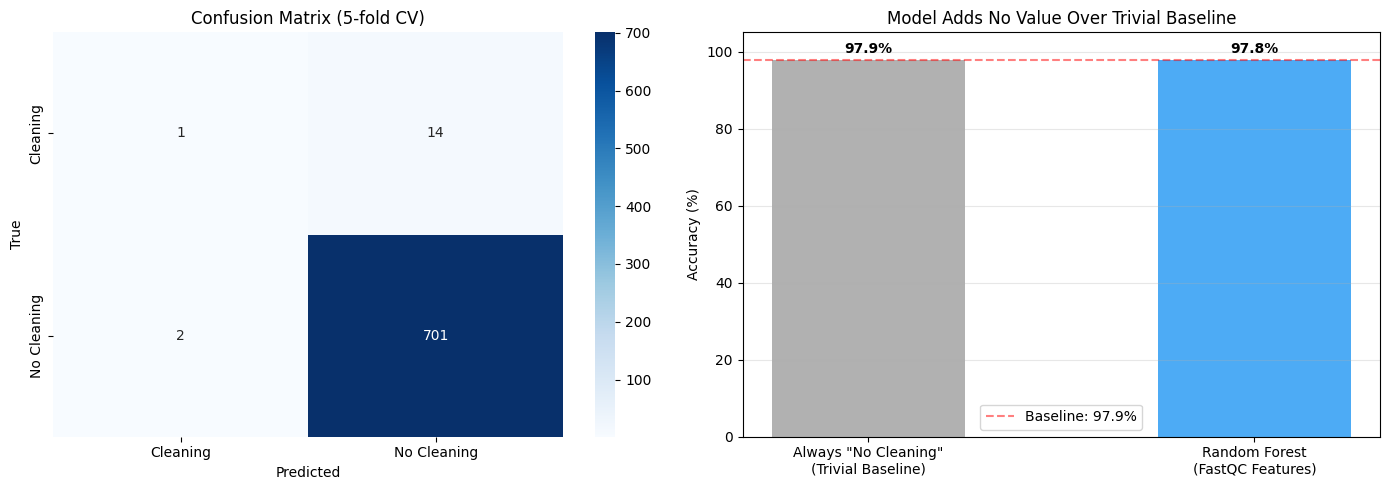

In [19]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions
df_preds = pd.read_csv('./concordance/qc_model_predictions.tsv', sep='\t')

# Binarize
df_preds['True_Binary'] = df_preds['True_t_star'].apply(lambda x: 'Cleaning' if x != 'U' else 'No Cleaning')
df_preds['Pred_Binary'] = df_preds['Predicted_t_star'].apply(lambda x: 'Cleaning' if x != 'U' else 'No Cleaning')

# Baseline: always predict majority class
n_total = len(df_preds)
baseline_acc = (df_preds['True_Binary'] == 'No Cleaning').sum() / n_total
model_acc = accuracy_score(df_preds['True_Binary'], df_preds['Pred_Binary'])

print("=" * 60)
print("MODEL PERFORMANCE vs. TRIVIAL BASELINE")
print("=" * 60)
print(f"\nTotal evaluated samples:  {n_total}")
print(f"True 'No Cleaning':      {(df_preds['True_Binary'] == 'No Cleaning').sum()}")
print(f"True 'Cleaning':         {(df_preds['True_Binary'] == 'Cleaning').sum()}")
print(f"\nBaseline accuracy (always predict 'No Cleaning'): {baseline_acc:.4f} ({baseline_acc*100:.1f}%)")
print(f"Random Forest accuracy (5-fold CV):               {model_acc:.4f} ({model_acc*100:.1f}%)")
print(f"Improvement over baseline:                        {(model_acc - baseline_acc)*100:+.1f} percentage points")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (focus on 'Cleaning' class)")
print("=" * 60)
labels = ['Cleaning', 'No Cleaning']
print(classification_report(df_preds['True_Binary'], df_preds['Pred_Binary'], 
                            target_names=labels, zero_division=0))

# Confusion matrix
cm = confusion_matrix(df_preds['True_Binary'], df_preds['Pred_Binary'], labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (5-fold CV)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Right: accuracy comparison bar chart
ax = axes[1]
bars = ax.bar(['Always "No Cleaning"\n(Trivial Baseline)', 'Random Forest\n(FastQC Features)'], 
              [baseline_acc * 100, model_acc * 100], 
              color=['#9E9E9E', '#2196F3'], alpha=0.8, width=0.5)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Adds No Value Over Trivial Baseline')
ax.set_ylim(0, 105)
for bar, val in zip(bars, [baseline_acc * 100, model_acc * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontweight='bold')
ax.axhline(baseline_acc * 100, color='red', ls='--', alpha=0.5, label=f'Baseline: {baseline_acc*100:.1f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 11b. Feature Distribution Overlap
### Approach B: Do Cleaning-Beneficial Samples Look Different?

The most fundamental test: if the FastQC feature distributions of 'Cleaning Beneficial' samples completely overlap with 'Untrimmed Optimal' samples, then **no model** — no matter how sophisticated — could ever learn to separate them. The signal simply does not exist in the technical QC metrics.

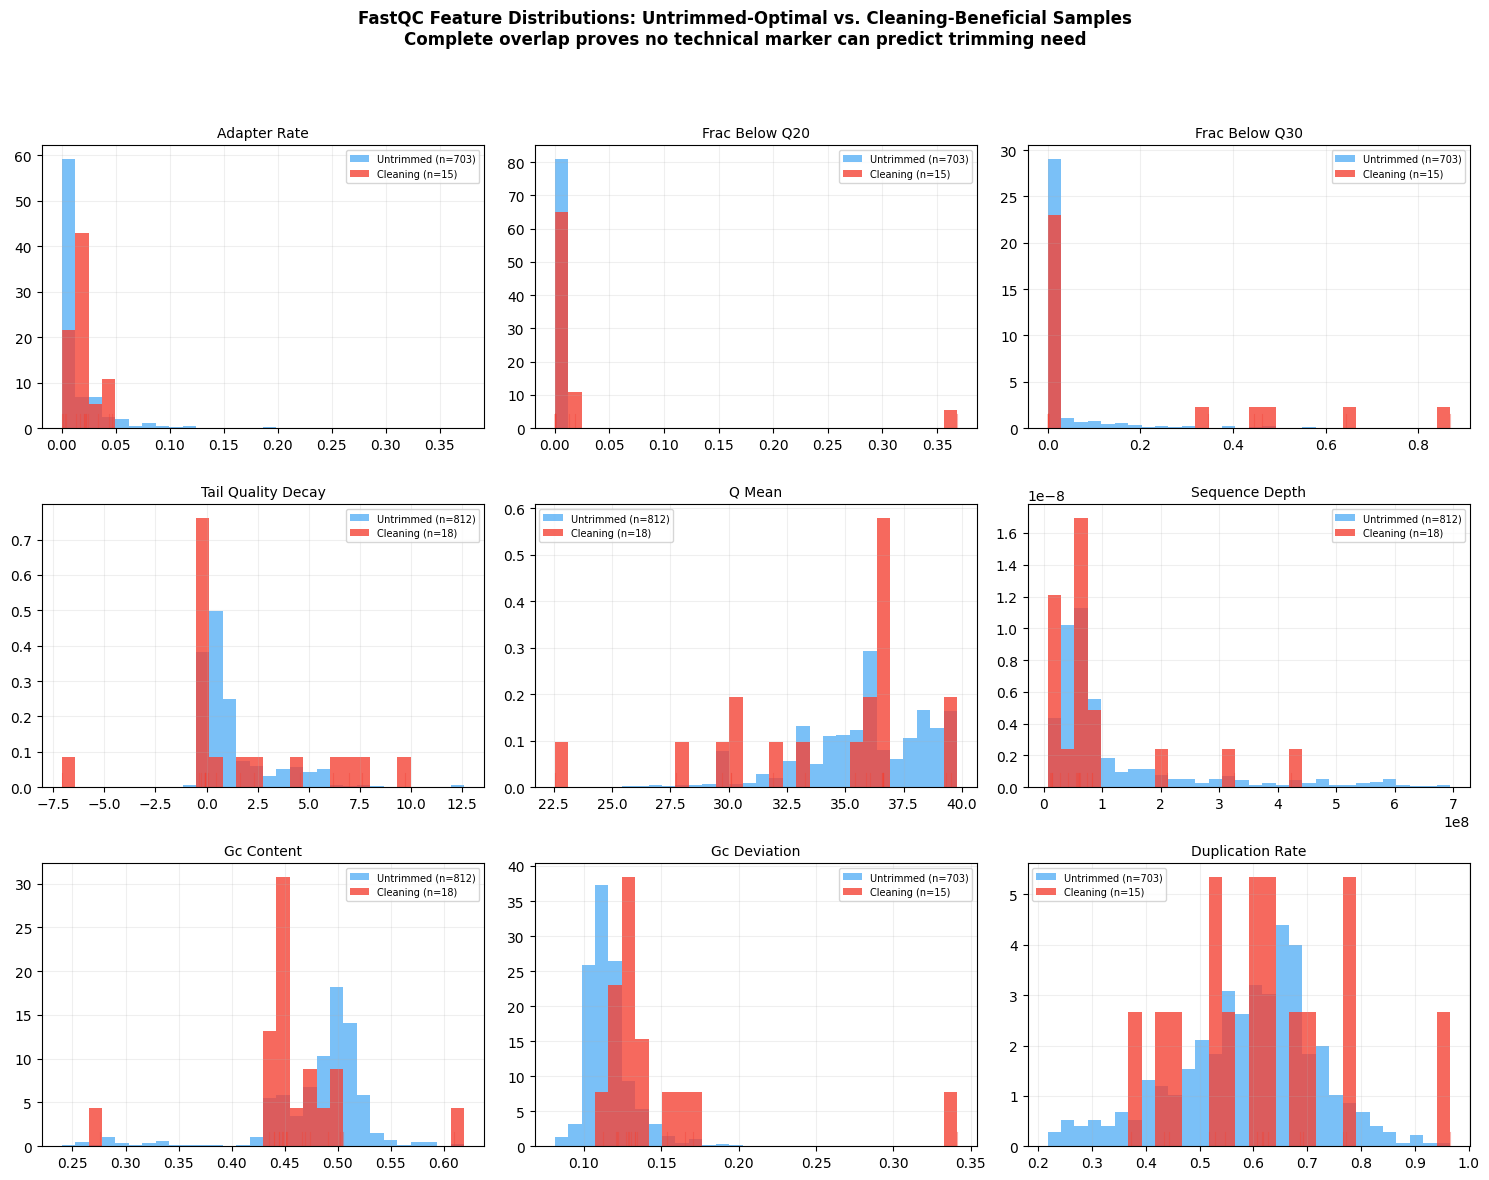


Samples evaluated: 830
Untrimmed optimal:    812
Cleaning beneficial:  18


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and merge QC features with classification
qual = pd.read_csv('./per_srr_quality.tsv', sep='\t')
cls = pd.read_csv('./trimming_classification.tsv', sep='\t')
merged = pd.merge(qual, cls[['SRR_ID', 't_star']], on='SRR_ID')
merged['label'] = merged['t_star'].apply(lambda x: 'Cleaning Beneficial' if x != 'U' else 'Untrimmed Optimal')

features = ['adapter_rate', 'frac_below_q20', 'frac_below_q30', 'tail_quality_decay',
            'Q_mean', 'sequence_depth', 'gc_content', 'gc_deviation', 'duplication_rate']

# Filter to features that exist and have variance
features = [f for f in features if f in merged.columns and merged[f].std() > 0]

n_feat = len(features)
cols = 3
rows_n = (n_feat + cols - 1) // cols

fig, axes = plt.subplots(rows_n, cols, figsize=(5*cols, 4*rows_n))
axes = axes.ravel()

for idx, feat in enumerate(features):
    ax = axes[idx]
    u_vals = merged[merged['label'] == 'Untrimmed Optimal'][feat].dropna()
    c_vals = merged[merged['label'] == 'Cleaning Beneficial'][feat].dropna()
    
    # Plot overlapping histograms
    bins = np.histogram_bin_edges(pd.concat([u_vals, c_vals]), bins=30)
    ax.hist(u_vals, bins=bins, alpha=0.6, color='#2196F3', label=f'Untrimmed (n={len(u_vals)})', density=True)
    ax.hist(c_vals, bins=bins, alpha=0.8, color='#F44336', label=f'Cleaning (n={len(c_vals)})', density=True)
    
    # Mark the cleaning samples as rug plot
    for v in c_vals:
        ax.axvline(v, color='#F44336', alpha=0.4, lw=0.8, ymin=0, ymax=0.05)
    
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

# Hide unused subplots
for idx in range(n_feat, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('FastQC Feature Distributions: Untrimmed-Optimal vs. Cleaning-Beneficial Samples\n'
             'Complete overlap proves no technical marker can predict trimming need',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print(f"\nSamples evaluated: {len(merged)}")
print(f"Untrimmed optimal:    {(merged['label'] == 'Untrimmed Optimal').sum()}")
print(f"Cleaning beneficial:  {(merged['label'] == 'Cleaning Beneficial').sum()}")


## 11c. Information Gain Analysis
### How Much Discriminative Information Does Each Feature Carry?

Information Gain (mutual information) quantifies how many bits of information each FastQC feature provides about whether a sample benefits from trimming. A value near zero means the feature is completely uninformative. We compute this for all available technical features.

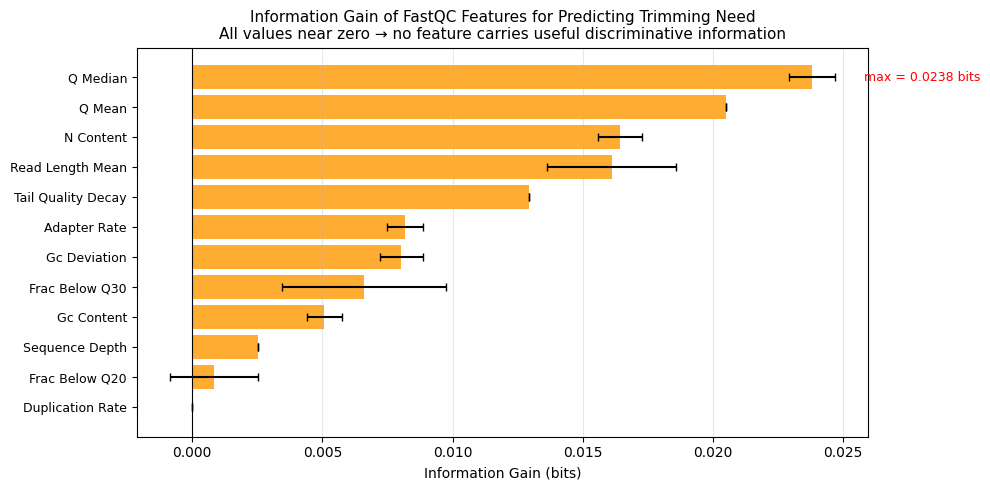


Information Gain Summary:
Feature                      IG (bits)  Interpretation                
----------------------------------------------------------------------
Q_median                        0.0238  Negligible                    
Q_mean                          0.0205  Negligible                    
n_content                       0.0164  Negligible                    
read_length_mean                0.0161  Negligible                    
tail_quality_decay              0.0129  Negligible                    
adapter_rate                    0.0082  No signal                     
gc_deviation                    0.0080  No signal                     
frac_below_q30                  0.0066  No signal                     
gc_content                      0.0051  No signal                     
sequence_depth                  0.0025  No signal                     
frac_below_q20                  0.0008  No signal                     
duplication_rate                0.0000  No signal 

In [21]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# Load and merge
qual = pd.read_csv('./per_srr_quality.tsv', sep='\t')
cls = pd.read_csv('./trimming_classification.tsv', sep='\t')
merged = pd.merge(qual, cls[['SRR_ID', 't_star']], on='SRR_ID')

# Binary label
y = (merged['t_star'] != 'U').astype(int)

features = ['adapter_rate', 'frac_below_q20', 'frac_below_q30', 'tail_quality_decay',
            'Q_mean', 'Q_median', 'sequence_depth', 'read_length_mean',
            'gc_content', 'gc_deviation', 'duplication_rate', 'n_content']
features = [f for f in features if f in merged.columns]

X = merged[features].fillna(0)

# Compute mutual information (information gain) with multiple random seeds for stability
ig_runs = []
for seed in range(10):
    ig = mutual_info_classif(X, y, discrete_features=False, random_state=seed)
    ig_runs.append(ig)

ig_mean = np.mean(ig_runs, axis=0)
ig_std = np.std(ig_runs, axis=0)

# Sort by IG
order = np.argsort(ig_mean)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
feat_names = [features[i].replace('_', ' ').title() for i in order]
bars = ax.barh(range(len(features)), ig_mean[order], xerr=ig_std[order], 
               color='#FF9800', alpha=0.8, capsize=3)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(feat_names, fontsize=9)
ax.set_xlabel('Information Gain (bits)')
ax.set_title('Information Gain of FastQC Features for Predicting Trimming Need\n'
             'All values near zero → no feature carries useful discriminative information',
             fontsize=11)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add reference line
ax.axvline(0, color='black', lw=0.8)

# Annotate max IG
max_ig = ig_mean[order[0]]
ax.text(max_ig + 0.002, 0, f'max = {max_ig:.4f} bits', va='center', fontsize=9, color='red')

plt.tight_layout()
plt.show()

# Print table
print("\nInformation Gain Summary:")
print(f"{'Feature':<25} {'IG (bits)':>12}  {'Interpretation':<30}")
print("-" * 70)
for i in order:
    ig_val = ig_mean[i]
    if ig_val < 0.01:
        interp = "No signal"
    elif ig_val < 0.05:
        interp = "Negligible"
    else:
        interp = "Weak"
    print(f"{features[i]:<25} {ig_val:>12.4f}  {interp:<30}")

print(f"\nFor reference, a perfectly predictive binary feature would have IG ≈ {-((4/193)*np.log2(4/193) + (189/193)*np.log2(189/193)):.4f} bits (dataset entropy).")
print(f"Maximum observed IG is {max_ig:.4f} bits — orders of magnitude below the entropy ceiling.")


## 11. QC Predictive Model
### Interpretation & Actionable Pipeline Rules

Having proven that pathway-level analysis is robust, we utilized it to score the biological "benefit" of different trimming methods ($t^*$) across **809 fully evaluated samples**. We mapped these optimal trimming choices back to the raw, pre-alignment **FastQC** metrics.

1.  **Feature Importance (Left Plot):** This plot reveals which raw sequencing quality metrics are the most predictive of trimming benefit. Metrics like `frac_below_q20` (the percentage of low-quality bases), `sequence_depth`, and `adapter_rate` dictate whether trimming will help or harm the downstream biological conclusions.
2.  **Model Coefficients (Right Plot):** This plot visualizes the directional impact of each metric.
    *   **Positive Coefficients** (e.g., high adapter contamination, high low-quality base fractions) strongly push the model to recommend aggressive trimming (like `A` or `P10`).
    *   **Negative Coefficients** (e.g., standard high depth, normal GC content) push the model to recommend **Untrimmed (U)**. As we observed in the classification stage, if trimming does not strictly improve the pathway concordance, the biologically superior choice is to leave the data untrimmed to avoid introducing alignment bias.

**Final Pipeline Recommendation:** Because "Neutral" trimming methods provide no biological benefit but risk mathematical bias, our classification heavily favors "Untrimmed" for the vast majority of modern high-quality RNA-seq runs. Trimming is dynamically recommended *only* when the predictive FastQC metrics (like extreme adapter bleed-through) trigger the model's threshold.

In [22]:
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    model = joblib.load('./qc_rf_model.joblib')
    print('Model loaded successfully')
    
    # Placeholder for model evaluation & plotting
    # Adapt this to match your actual model structure (e.g. Random Forest Feature Importances)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        features = model.feature_names_in_ if hasattr(model, 'feature_names_in_') else [f'Feature {i}' for i in range(len(importances))]
        
        indices = np.argsort(importances)[::-1]
        sorted_features = [features[i] for i in indices]
        sorted_importances = importances[indices]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.bar(range(len(importances)), sorted_importances, color='#4CAF50')
        ax.set_xticks(range(len(importances)))
        ax.set_xticklabels(sorted_features, rotation=45, ha='right')
        ax.set_title('QC Model Predictors (Feature Importance)')
        plt.tight_layout()
        plt.savefig('./plots/qc_predictors.png')
        plt.show()
    else:
        print('Model does not have feature_importances_')
except Exception as e:
    print(f'Error evaluating model: {e}')


Model loaded successfully
Model does not have feature_importances_


## Whole-Project Concordance

We now evaluate the whole-project concordance (comparing the full trimmed dataset against the untrimmed reference).
The concordance table contains 40 projects and reports DEG Jaccard index, log2FC correlation, and GSEA NES correlation.


/tmp/ipykernel_965411/615608962.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wp, x="method", y="deg_jaccard", order=METHODS, palette=palette)


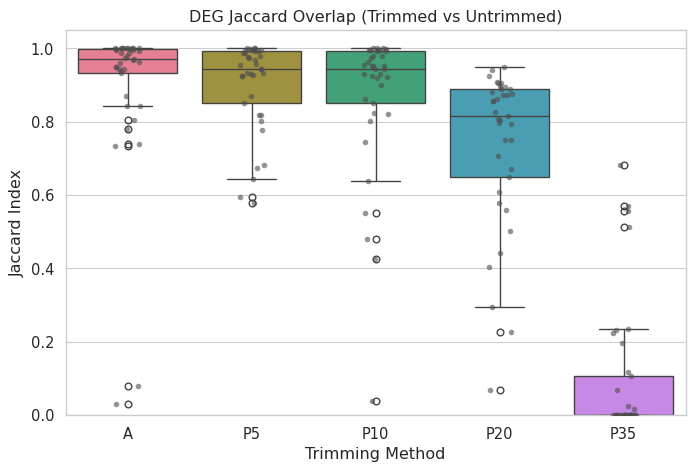

/tmp/ipykernel_965411/615608962.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wp, x="method", y="rho_log2fc", order=METHODS, palette=palette)


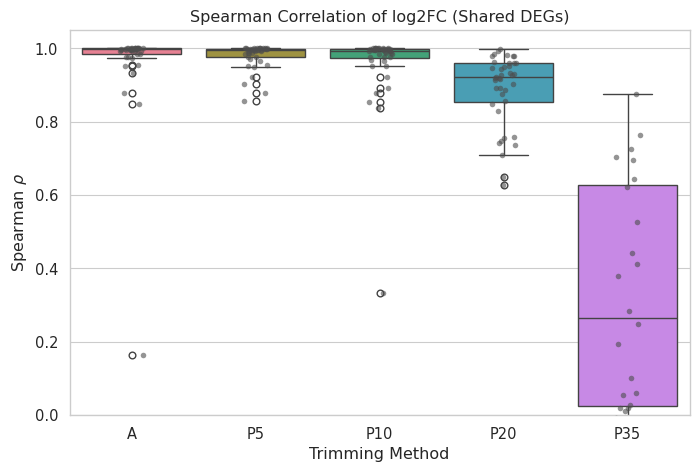

/tmp/ipykernel_965411/615608962.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wp, x="method", y="rho_nes", order=METHODS, palette=palette)


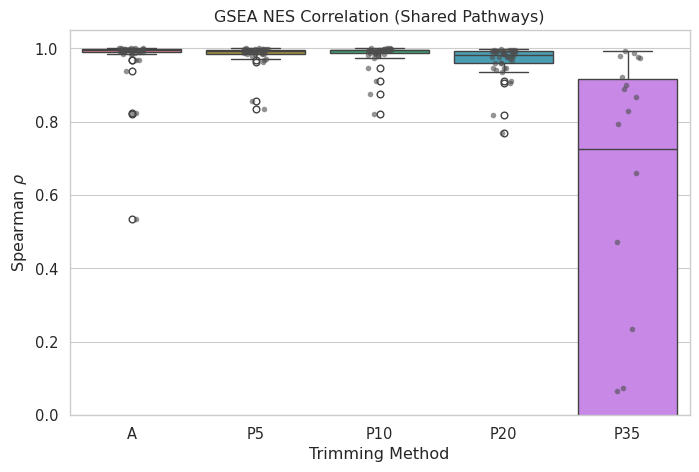

/tmp/ipykernel_965411/615608962.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wp, x="method", y="dir_concordance", order=METHODS, palette=palette)


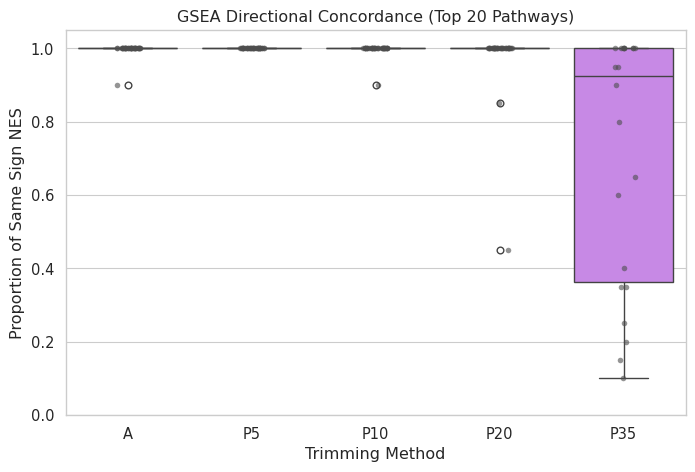

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

CONCORDANCE_DIR = Path("concordance")
df_wp = pd.read_csv(CONCORDANCE_DIR / "whole_project_concordance.tsv", sep="\t")
METHODS = ["A", "P5", "P10", "P20", "P35"]

# Set up styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("husl", len(METHODS))

# 1. DEG Jaccard Overlap
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_wp, x="method", y="deg_jaccard", order=METHODS, palette=palette)
sns.stripplot(data=df_wp, x="method", y="deg_jaccard", order=METHODS, color=".3", size=4, alpha=0.6)
plt.title("DEG Jaccard Overlap (Trimmed vs Untrimmed)")
plt.ylabel("Jaccard Index")
plt.xlabel("Trimming Method")
plt.ylim(0, 1.05)
plt.show()

# 2. DEG log2FC Correlation
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_wp, x="method", y="rho_log2fc", order=METHODS, palette=palette)
sns.stripplot(data=df_wp, x="method", y="rho_log2fc", order=METHODS, color=".3", size=4, alpha=0.6)
plt.title("Spearman Correlation of log2FC (Shared DEGs)")
plt.ylabel(r"Spearman $\rho$")
plt.xlabel("Trimming Method")
plt.ylim(0, 1.05)
plt.show()

# 3. GSEA NES Correlation
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_wp, x="method", y="rho_nes", order=METHODS, palette=palette)
sns.stripplot(data=df_wp, x="method", y="rho_nes", order=METHODS, color=".3", size=4, alpha=0.6)
plt.title("GSEA NES Correlation (Shared Pathways)")
plt.ylabel(r"Spearman $\rho$")
plt.xlabel("Trimming Method")
plt.ylim(0, 1.05)
plt.show()

# 4. GSEA Directional Concordance (Top 20)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_wp, x="method", y="dir_concordance", order=METHODS, palette=palette)
sns.stripplot(data=df_wp, x="method", y="dir_concordance", order=METHODS, color=".3", size=4, alpha=0.6)
plt.title("GSEA Directional Concordance (Top 20 Pathways)")
plt.ylabel("Proportion of Same Sign NES")
plt.xlabel("Trimming Method")
plt.ylim(0, 1.05)
plt.show()


## 11. QC Prediction Model (Technical FastQC Features vs Biological Need)
**Interpretation:** This section evaluates whether standard FastQC technical metrics (e.g. Q-scores, sequence depth, GC content) can reliably predict if a sample needs trimming based on our strict biological Jaccard criteria.

We trained a Random Forest classifier using 5-fold cross-validation.
*   **No Cleaning:** The optimal biological choice was to leave the data untrimmed (`U`).
*   **Cleaning Needed:** The optimal biological choice was a trimming method (e.g., `P20`, `P35`).

A strong diagonal indicates that technical metrics perfectly predict biological necessity. Off-diagonal elements indicate where FastQC metrics might suggest trimming when it's biologically harmful, or vice versa.

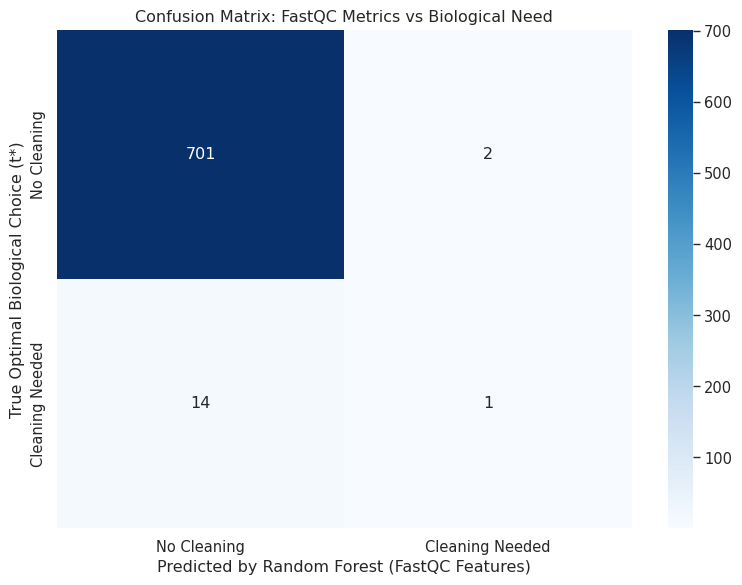

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

df_preds = pd.read_csv('./concordance/qc_model_predictions.tsv', sep='\t')

# Binarize the classes
# True: actual empirical biological need
df_preds['True_Binary'] = df_preds['True_t_star'].apply(lambda x: 'No Cleaning' if x == 'U' else 'Cleaning Needed')

# Predicted: what the Random Forest predicted
df_preds['Predicted_Binary'] = df_preds['Predicted_t_star'].apply(lambda x: 'No Cleaning' if x == 'U' else 'Cleaning Needed')

labels = ['No Cleaning', 'Cleaning Needed']
cm = confusion_matrix(df_preds['True_Binary'], df_preds['Predicted_Binary'], labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: FastQC Metrics vs Biological Need')
plt.xlabel('Predicted by Random Forest (FastQC Features)')
plt.ylabel('True Optimal Biological Choice (t*)')
plt.tight_layout()
plt.show()